In [1]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch

In [2]:
# Load the file into a DataFrame
headlines_train_seen = pd.read_parquet('data/headlines_seen_train.parquet')
bars_df = pd.read_parquet("data/bars_seen_train.parquet")
# Display the first few rows
print(headlines_train_seen.head())

   session                                           headline  bar_ix
0        0  Relvos Biosciences opens new office in Southea...       6
1        0  Orevex Renewables secures $500M contract with ...      12
2        0  Relvos Biosciences names new head of precision...      14
3        0  Calvis Sciences secures $650M contract with a ...      20
4        0  Yorvov Pharmaceuticals secures $180M contract ...      22


In [3]:
headlines_train_seen['session'].unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [4]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_session_with_news(
    bars_df,
    headlines_df,
    session_n,
    price_col="close",
    figsize=(14, 6),
    show_headlines=True,
    rotate_labels=90,
):
    """
    Plot price movement for a given session with vertical lines for headlines.

    Parameters
    ----------
    bars_df : pd.DataFrame
        Must contain columns:
        ['session', 'bar_ix', 'open', 'high', 'low', 'close']

    headlines_df : pd.DataFrame
        Must contain columns:
        ['session', 'headline', 'bar_ix']

    session_n : int
        Session number to plot.

    price_col : str
        Which price column to plot ('open', 'high', 'low', 'close').

    figsize : tuple
        Figure size.

    show_headlines : bool
        If True, annotate headlines on chart.

    rotate_labels : int
        Rotation angle for headline labels.
    """

    # Filter data
    bars = bars_df[bars_df["session"] == session_n].copy()
    news = headlines_df[headlines_df["session"] == session_n].copy()

    if bars.empty:
        print(f"No bars found for session {session_n}")
        return

    # Sort bars
    bars = bars.sort_values("bar_ix")
    news = news.sort_values("bar_ix")

    fig, ax = plt.subplots(figsize=figsize)

    # Plot price line
    ax.plot(
        bars["bar_ix"],
        bars[price_col],
        lw=2,
        label=f"{price_col.title()} Price"
    )

    # Vertical lines for headlines
    for _, row in news.iterrows():
        x = row["bar_ix"]

        ax.axvline(
            x=x,
            linestyle="--",
            alpha=0.6,
            linewidth=1
        )

        if show_headlines:
            ax.text(
                x,
                bars[price_col].max(),
                row["headline"],
                rotation=rotate_labels,
                va="top",
                ha="right",
                fontsize=8,
                alpha=0.8
            )

    ax.set_title(f"Session {session_n}: Price Movement + Headlines")
    ax.set_xlabel("bar_ix")
    ax.set_ylabel(price_col)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

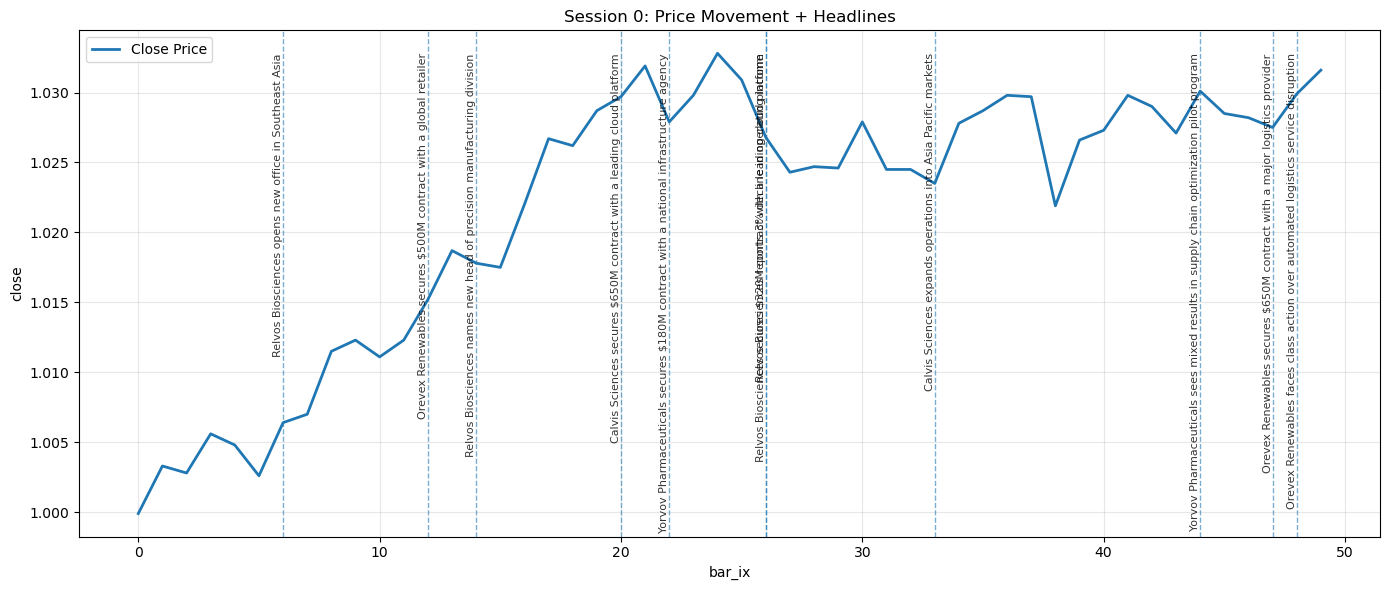

In [5]:
plot_session_with_news(bars_df, headlines_train_seen, 0)

In [6]:
def headlines_per_session(headlines_df, session_n):
    headlines_data = headlines_df[headlines_df["session"] == session_n].copy()
    headlines_list = headlines_data["headline"].copy()
    bar_idx_list = headlines_df["bar_ix"].copy().to_list()
    
    headline_idx_pairs = [(x, y) for x, y in zip(bar_idx_list, headlines_list)]
    print(len(headline_idx_pairs))
    for idx, headline in headline_idx_pairs:
        print(headline, idx)
    

In [7]:
headlines_per_session(headlines_train_seen, 0)

11
Relvos Biosciences opens new office in Southeast Asia 6
Orevex Renewables secures $500M contract with a global retailer 12
Relvos Biosciences names new head of precision manufacturing division 14
Calvis Sciences secures $650M contract with a leading cloud platform 20
Yorvov Pharmaceuticals secures $180M contract with a national infrastructure agency 22
Relvos Biosciences reports 3% decline in operating income 26
Relvos Biosciences secures $320M contract with a leading cloud platform 26
Calvis Sciences expands operations into Asia Pacific markets 33
Yorvov Pharmaceuticals sees mixed results in supply chain optimization pilot program 44
Orevex Renewables secures $650M contract with a major logistics provider 47
Orevex Renewables faces class action over automated logistics service disruption 48


In [13]:
pharma_cluster = [
"Calvis Sciences",
"Calvos Genomics",
"Frelis Genomics",
"Grevel Diagnostics",
"Grevon Biotech",
"Jorvix Diagnostics",
"Krevum Pharmaceuticals",
"Myrnon Therapeutics",
"Nerval Biopharma",
"Relvos Biosciences",
"Wyrnik Sciences",
"Xelvol Biotech",
"Yorvov Pharmaceuticals",
"Zelvix Therapeutics",
"Zelvon Biosciences",
"Zrovum Biopharma"]

energy_cluster = [
"Jorvis Fuels",
"Kelvik Power",
"Kelvos Resources",
"Nerven Grid",
"Nolvol Resources",
"Orevex Renewables",
"Orevov Solutions",
"Plevep Power",
"Plevik Energy",
"Relvon Fuels",
"Strynal Industries",
"Ulvon Renewables",
"Urvel Grid",
"Wyrnor Solutions",
"Zelval Energy",
"Zrovex Industries"]

commerce_cluster = [
"Arnik Commerce",
"Arnos Marketplace",
"Crevol Retail",
"Frelex Outlets",
"Halvav Brands",
"Holtar Stores",
"Ixenis Outlets",
"Jorval Trading",
"Joval Brands",
"Nolvav Commerce",
"Orevar Marketplace",
"Pleven Trading",
"Talvyn Goods",
"Varvov Retail",
"Xovep Stores",
"Xovol Goods"]

money_cluster = [
"Creven Securities",
"Ervan Capital",
"Halven Investments",
"Halvix Holdings",
"Holtum Asset",
"Ilval Financial",
"Jorvyl Securities",
"Jovik Asset",
"Krevan Investments",
"Plevum Partners",
"Plevyl Advisors",
"Talvix Holdings",
"Wrelal Financial",
"Yorval Partners",
"Zelvel Capital",
"Zrovov Advisors"]

hardware_cluster = [
"Brevep Systems",
"Brevon Microchips",
"Crevex Labs",
"Dralol Computing",
"Frelol Software",
"Halvax Networks",
"Ixenix Technologies",
"Jovor Networks",
"Myrnep Technologies",
"Nolvis Devices",
"Prynis Systems",
"Relvan Software",
"Talvep Computing",
"Ulvyn Microchips",
"Volval Devices",
"Yorven Labs"
]

clusters = [pharma_cluster, energy_cluster, commerce_cluster, money_cluster, hardware_cluster]

cluster_map = {}
for i, cluster_list in enumerate(clusters):
    for company in cluster_list:
        cluster_map[company] = i

In [20]:
def extract_headline_stats(headline_df):
    if torch.cuda.is_available():
        device = 0 # NVIDIA GPU
    elif torch.backends.mps.is_available():
        device = "mps" # Apple Silicon
    else:
        device = -1 # CPU
    
    model_name = "ProsusAI/finbert"
    pipe = pipeline("sentiment-analysis", model=model_name, batch = 32, device=device, top_k=None)

    headlines = headline_df['headline'].tolist()
    results = pipe(headlines, batch_size=32, truncation=True)


    # 5. Merge results back to DataFrame
    headline_stats = headline_df.copy()
    unwrapped_data = []

    for res in results:
    
        # FinBERT labels are often 'positive', 'negative', 'neutral'
        # Use a dictionary comprehension to map them reliably
        scores = {item['label']: item['score'] for item in res}
    
        # Identify the 'winner' (the one with the highest probability)
        decided_label = max(scores, key=scores.get)
    
        unwrapped_data.append({
            'decided_label': decided_label,
            'prob_positive': scores.get('positive', 0),
            'prob_negative': scores.get('negative', 0),
            'prob_neutral': scores.get('neutral', 0)
        })

    # 2. Convert to DataFrame
    scores_df = pd.DataFrame(unwrapped_data)

    headline_stats = headline_stats.reset_index(drop=True)
    headline_stats = pd.concat([headline_stats, scores_df], axis=1)

    # --- SCORE 1: Linear Continuum (The Standard) ---
    # Range: -1 to 1. Factual/Neutral headlines stay close to 0.
    headline_stats['linear_score'] = headline_stats['prob_positive'] - headline_stats['prob_negative']

    # --- SCORE 2: Directional Polarity (The Hidden Signal) ---
    # Range: -1 to 1. This "zooms in" on the positive/negative lean, even if neutral won.
    # We add a small epsilon (1e-9) to avoid division by zero
    headline_stats['polarity_score'] = (
        (headline_stats['prob_positive'] - headline_stats['prob_negative']) / 
        (headline_stats['prob_positive'] + headline_stats['prob_negative'] + 1e-9)
    )
    
    headline_stats['headline'] = headline_stats['headline'].str.split().str[:2].str.join(' ')
    
    headline_stats['cluster'] = headline_stats['headline'].map(cluster_map)
    headline_stats['cluster'] = headline_stats['cluster'].fillna(-1).astype(int)
    
    return headline_stats
    

In [15]:
headline_stats_0 = extract_headline_stats(headlines_train_seen[headlines_train_seen["session"] == 0])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
headline_stats_0

,session,headline,bar_ix,decided_label,prob_positive,prob_negative,prob_neutral,linear_score,polarity_score,cluster
0,0,Relvos Biosciences,6,neutral,0.387032,0.013454,0.599514,0.373578,0.932811,0
1,0,Orevex Renewables,12,positive,0.948091,0.012295,0.039614,0.935795,0.974395,1
2,0,Relvos Biosciences,14,neutral,0.061307,0.040272,0.898421,0.021034,0.207074,0
3,0,Calvis Sciences,20,positive,0.945060,0.010088,0.044852,0.934971,0.978876,0
4,0,Yorvov Pharmaceuticals,22,positive,0.947761,0.012083,0.040155,0.935678,0.974823,0
5,0,Relvos Biosciences,26,negative,0.008312,0.974797,0.016890,-0.966485,-0.983090,0
6,0,Relvos Biosciences,26,positive,0.948155,0.012102,0.039743,0.936053,0.974793,0
7,0,Calvis Sciences,33,positive,0.760141,0.008625,0.231234,0.751516,0.977561,0
8,0,Yorvov Pharmaceuticals,44,negative,0.026838,0.947266,0.025896,-0.920428,-0.944897,0
9,0,Orevex Renewables,47,positive,0.950261,0.013908,0.035830,0.936353,0.971149,1


In [21]:
total_headlines = extract_headline_stats(headlines_train_seen)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
total_headlines.head(20)

,session,headline,bar_ix,decided_label,prob_positive,prob_negative,prob_neutral,linear_score,polarity_score,cluster
0,0,Relvos Biosciences,6,neutral,0.387032,0.013454,0.599514,0.373578,0.932811,0
1,0,Orevex Renewables,12,positive,0.948091,0.012295,0.039614,0.935795,0.974395,1
2,0,Relvos Biosciences,14,neutral,0.061307,0.040272,0.898421,0.021034,0.207074,0
3,0,Calvis Sciences,20,positive,0.945060,0.010088,0.044852,0.934971,0.978876,0
4,0,Yorvov Pharmaceuticals,22,positive,0.947761,0.012083,0.040155,0.935678,0.974823,0
5,0,Relvos Biosciences,26,negative,0.008312,0.974797,0.016890,-0.966485,-0.983090,0
6,0,Relvos Biosciences,26,positive,0.948155,0.012102,0.039743,0.936053,0.974793,0
7,0,Calvis Sciences,33,positive,0.760141,0.008625,0.231234,0.751516,0.977561,0
8,0,Yorvov Pharmaceuticals,44,negative,0.026838,0.947266,0.025896,-0.920428,-0.944897,0
9,0,Orevex Renewables,47,positive,0.950261,0.013908,0.035830,0.936353,0.971149,1


In [23]:
total_headlines.isnull().sum()

session           0
headline          0
bar_ix            0
decided_label     0
prob_positive     0
prob_negative     0
prob_neutral      0
linear_score      0
polarity_score    0
cluster           0
dtype: int64

In [24]:
(total_headlines['cluster'] == -1).sum()

0